<a href="https://colab.research.google.com/github/4GTTN/Colab/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Common

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!unzip -q '/content/drive/MyDrive/Colab Notebooks/IntellectualSystems/data/lab6/Writers/Тексты писателей.zip' -d /content/texts

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Embedding, SpatialDropout1D, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
import time

In [ ]:
className = ["О. Генри", "Стругацкие", "Булгаков", "Саймак", "Фрай", "Брэдберри"]
nClasses = len(className)

In [ ]:
def readText(fileName):
  f = open(fileName, 'r')
  text = f.read()
  text = text.replace("\n", " ")
  return text

In [ ]:
def getSetFromIndexes(wordIndexes, xLen, step):
  xSample = []
  wordsLen = len(wordIndexes)
  index = 0
  while (index + xLen <= wordsLen):
    xSample.append(wordIndexes[index:index+xLen])
    index += step
  return xSample

In [ ]:
def createSetsMultiClasses(wordIndexes, xLen, step):
  nClasses = len(wordIndexes)
  classesXSamples = []
  for wI in wordIndexes:
    classesXSamples.append(getSetFromIndexes(wI, xLen, step))
  xSamples = []
  ySamples = []
  for t in range(nClasses):
    xT = classesXSamples[t]
    for i in range(len(xT)):
      xSamples.append(xT[i])
      ySamples.append(utils.to_categorical(t, nClasses))
  xSamples = np.array(xSamples)
  ySamples = np.array(ySamples)
  return (xSamples, ySamples)

# Light

## Задания:

### **Задание 1** Запустите нейронку c bag of words (01) при разных maxWordsCount
*   100
*   1000
*   10000
*   50000

100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5528 - loss: 1.1953 - val_accuracy: 0.5013 - val_loss: 1.3120
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6939 - loss: 0.8339 - val_accuracy: 0.5414 - val_loss: 1.2061
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7326 - loss: 0.7371 - val_accuracy: 0.5178 - val_loss: 1.2864
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7536 - loss: 0.6700 - val_accuracy: 0.5335 - val_loss: 1.3208
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7776 - loss: 0.6085 - val_accuracy: 0.5139 - val_loss: 1.4128
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7965 - loss: 0.5590 - val_accuracy: 0.5085 - val_loss: 1.4922
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8075 - loss: 0.5246 - val_accuracy: 0.4798 - val_loss: 1.6411
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8269 - loss: 0.4856 - val_accuracy: 0.

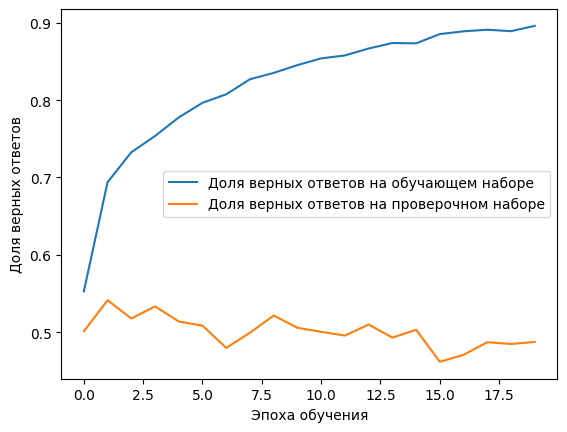

1000
Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9348 - loss: 0.2100 - val_accuracy: 0.8210 - val_loss: 0.5431
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9995 - loss: 0.0111 - val_accuracy: 0.8353 - val_loss: 0.4752
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9999 - loss: 0.0047 - val_accuracy: 0.8419 - val_loss: 0.4570
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.8461 - val_loss: 0.4554
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8388 - val_loss: 0.4740
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.8419 - val_loss: 0.4724
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 8.8301e-04 - val_accuracy: 0.8389 - val_loss: 0.4851
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 7.3269e-

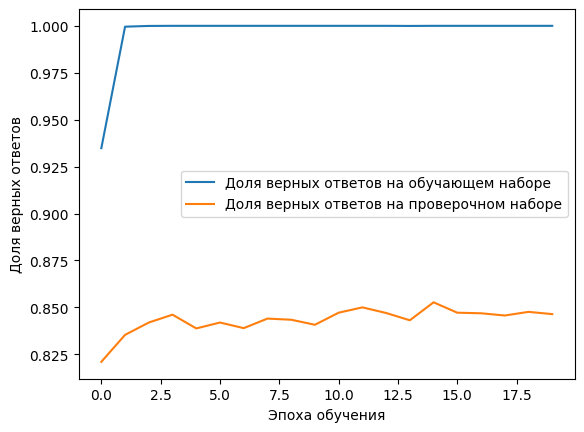

10000
Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9821 - loss: 0.0608 - val_accuracy: 0.8832 - val_loss: 0.4081
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 1.0000 - loss: 7.2778e-04 - val_accuracy: 0.8851 - val_loss: 0.3482
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 65ms/step - accuracy: 1.0000 - loss: 3.5742e-04 - val_accuracy: 0.8827 - val_loss: 0.3407
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 1.0000 - loss: 2.2601e-04 - val_accuracy: 0.8850 - val_loss: 0.3329
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 9s 64ms/step - accuracy: 1.0000 - loss: 1.4790e-04 - val_accuracy: 0.8857 - val_loss: 0.3320
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - accuracy: 1.0000 - loss: 1.1494e-04 - val_accuracy: 0.8850 - val_loss: 0.3309
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 1.0000 - loss: 9.1706e-05 - val_accuracy: 0.8865 - val_loss: 0.3277
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 86ms/step - accuracy:

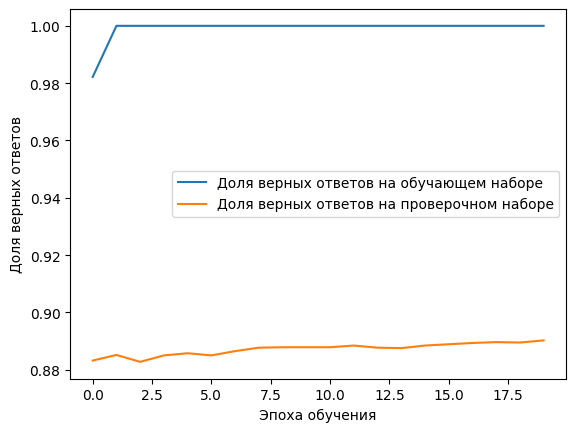

20000
Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step - accuracy: 0.9850 - loss: 0.0479 - val_accuracy: 0.8886 - val_loss: 0.3899
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 108ms/step - accuracy: 1.0000 - loss: 3.0682e-04 - val_accuracy: 0.8905 - val_loss: 0.3416
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 1.0000 - loss: 1.5576e-04 - val_accuracy: 0.8862 - val_loss: 0.3392
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 101ms/step - accuracy: 1.0000 - loss: 1.0165e-04 - val_accuracy: 0.8850 - val_loss: 0.3373
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 100ms/step - accuracy: 1.0000 - loss: 6.6952e-05 - val_accuracy: 0.8892 - val_loss: 0.3277
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 103ms/step - accuracy: 1.0000 - loss: 5.3209e-05 - val_accuracy: 0.8904 - val_loss: 0.3246
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 1.0000 - loss: 4.0791e-05 - val_accuracy: 0.8916 - val_loss: 0.3225
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step

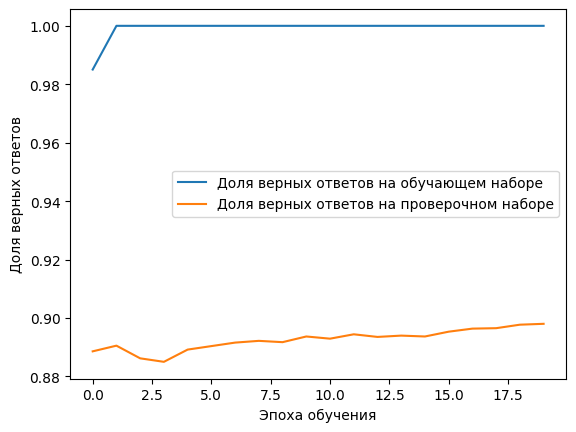

In [ ]:
words_counts_arr = [100, 1000, 10000, 20000]

trainText = []
testText = []
for i in className:
  for j in os.listdir('texts/'):
    if i in j:
      if 'Обучающая' in j:
        trainText.append(readText('texts/' + j))
      if 'Тестовая' in j:
        testText.append(readText('texts/' + j))

for cnt in words_counts_arr:
  print(cnt)

  tokenizer = Tokenizer(num_words=cnt, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0', lower=True, split=' ', oov_token='unknown', char_level=False)
  tokenizer.fit_on_texts(trainText)
  trainWordIndexes = tokenizer.texts_to_sequences(trainText)
  testWordIndexes = tokenizer.texts_to_sequences(testText)

  xLen = 1000
  step = 100
  xTrain, yTrain = createSetsMultiClasses(trainWordIndexes, xLen, step)
  xTest, yTest = createSetsMultiClasses(testWordIndexes, xLen, step)
  xTrain01 = tokenizer.sequences_to_matrix(xTrain.tolist())
  xTest01 = tokenizer.sequences_to_matrix(xTest.tolist())

  model01 = Sequential()
  model01.add(Dense(200, input_dim=cnt, activation="relu"))
  model01.add(Dropout(0.25))
  model01.add(BatchNormalization())
  model01.add(Dense(6, activation='sigmoid'))
  model01.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
  history = model01.fit(xTrain01,
                        yTrain,
                        epochs=20,
                        batch_size=128,
                        validation_data=(xTest01, yTest))
  scores = model01.evaluate(xTest01, yTest, verbose=1)

  print(f'\n{scores}')
  print("Доля верных ответов на тестовых данных: ", round(scores[1] * 100, 2), "%", sep="")

  plt.plot(history.history['accuracy'],
          label='Доля верных ответов на обучающем наборе')
  plt.plot(history.history['val_accuracy'],
          label='Доля верных ответов на проверочном наборе')
  plt.xlabel('Эпоха обучения')
  plt.ylabel('Доля верных ответов')
  plt.legend()
  plt.show()

**Вывод:**
В ходе проведения тестирования были выявлены следующие результаты:
* 100: 48.76%
* 1000: 84.64%
* 10000: 89.02%
* 20000: 89.8%

Из результатов тестирования можнов выделить явную взаимосвязь между количеством слов и точностью сети.

### **Задание 2.** Запустите нейронку c bag of words (01) при maxWordsCount = 20000 и разных архитектурах
*   Поменяйте количество нейронов в слоях
*   Поменяйте количество слоев
*   Поменяйте активационные функции слоев

In [ ]:
def train_and_show_results(model):
  model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
  model.summary()


  history = model.fit(xTrain01,
                      yTrain,
                      epochs=40,
                      batch_size=128,
                      validation_data=(xTest01, yTest))

  scores = model.evaluate(xTest01, yTest, verbose=1)

  print(f'\n{scores}')
  print("Доля верных ответов на тестовых данных: ", round(scores[1] * 100, 2), "%", sep="")

  plt.plot(history.history['accuracy'],
          label='Доля верных ответов на обучающем наборе')
  plt.plot(history.history['val_accuracy'],
          label='Доля верных ответов на проверочном наборе')
  plt.xlabel('Эпоха обучения')
  plt.ylabel('Доля верных ответов')
  plt.legend()
  plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DIFFERENT LAYERS COUNT


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │     4,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,021,306 (15.34 MB)

 Trainable params: 4,021,106 (15.34 MB)

 Non-trainable params: 200 (800.00 B)

Epoch 1/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 23s 148ms/step - accuracy: 0.9668 - loss: 0.1049 - val_accuracy: 0.8966 - val_loss: 0.4366
Epoch 2/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9058 - val_loss: 0.3165
Epoch 3/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 1.0000 - loss: 9.0300e-04 - val_accuracy: 0.9091 - val_loss: 0.2855
Epoch 4/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 1.0000 - loss: 5.6184e-04 - val_accuracy: 0.9037 - val_loss: 0.2863
Epoch 5/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 22s 114ms/step - accuracy: 1.0000 - loss: 4.1229e-04 - val_accuracy: 0.9047 - val_loss: 0.2809
Epoch 6/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - accuracy: 1.0000 - loss: 3.2071e-04 - val_accuracy: 0.9118 - val_loss: 0.2699
Epoch 7/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 1.0000 - loss: 2.6436e-04 - val_accuracy: 0.9161 - val_loss: 0.2598
Epoch 8/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accurac

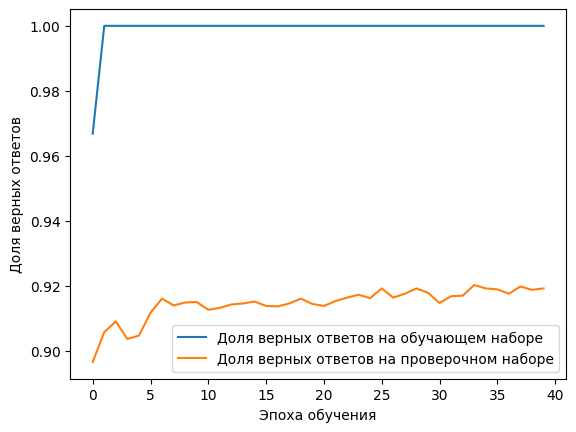

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 200)            │     4,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,025,856 (15.36 MB)

 Trainable params: 4,025,756 (15.36 MB)

 Non-trainable params: 100 (400.00 B)

Epoch 1/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.9240 - loss: 0.2494 - val_accuracy: 0.8959 - val_loss: 0.5487
Epoch 2/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.9997 - loss: 0.0106 - val_accuracy: 0.9122 - val_loss: 0.3239
Epoch 3/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 118ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 0.9170 - val_loss: 0.2650
Epoch 4/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 120ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 0.9155 - val_loss: 0.2571
Epoch 5/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 109ms/step - accuracy: 0.9999 - loss: 0.0027 - val_accuracy: 0.9162 - val_loss: 0.2525
Epoch 6/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.9153 - val_loss: 0.2553
Epoch 7/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 111ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9149 - val_loss: 0.2541
Epoch 8/40
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 109ms/step - accuracy: 1.0000 - loss: 0

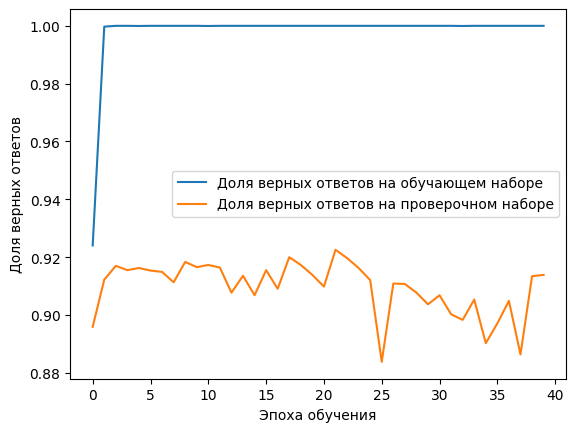

In [ ]:
trainText = []
testText = []
for i in className:
  for j in os.listdir('texts/'):
    if i in j:
      if 'Обучающая' in j:
        trainText.append(readText('texts/' + j))
      if 'Тестовая' in j:
        testText.append(readText('texts/' + j))


cur_time = time.time()
maxWordsCount = 20000
tokenizer = Tokenizer(num_words=maxWordsCount, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0', lower=True, split=' ', oov_token='unknown', char_level=False)
tokenizer.fit_on_texts(trainText)
trainWordIndexes = tokenizer.texts_to_sequences(trainText)
testWordIndexes = tokenizer.texts_to_sequences(testText)

hidden_layer_weights = [100, 200, 1000]
activations = [['sigmoid', 'sigmoid'], ['sigmoid', 'softmax'], ['tanh', 'softmax']]

xLen = 1000
step = 100
xTrain, yTrain = createSetsMultiClasses(trainWordIndexes, xLen, step)
xTest, yTest = createSetsMultiClasses(testWordIndexes, xLen, step)
xTrain01 = tokenizer.sequences_to_matrix(xTrain.tolist())
xTest01 = tokenizer.sequences_to_matrix(xTest.tolist())

models = []
models.clear()
models.append(
    Sequential([
      Dense(200, activation='relu', input_dim=maxWordsCount),
      Dropout(0.1),
      Dense(100, activation='sigmoid'),
      Dropout(0.25),
      BatchNormalization(),
      Dense(6, activation='softmax')
    ])
)
models.append(
    Sequential([
      Dense(200, activation='relu', input_dim=maxWordsCount),
      Dropout(0.1),
      Dense(100, activation='sigmoid'),
      Dropout(0.1),
      Dense(50, activation='sigmoid'),
      Dropout(0.25),
      BatchNormalization(),
      Dense(6, activation='softmax')
    ])
)

print('===================================')
print('DIFFERENT LAYERS COUNT')
for model in models:
  train_and_show_results(model)
print('===================================')



При проведении тестирования с изменением гиперпараметров сети были следующие изменения:

- Веса скрытого слоя:
  - 100 нейронов: 90.25%
  - 200 нейронов: 88.77%
  - 300 нейронов: 87.18%
- Функции активации:
  - sigmoid+sigmoid: 91.59%
  - sgimoid+softmax: 90.53%
  - tanh+softmax: 88.26%
- Количество скрытых слоев:
  - 2 скрытых слоя: 91.92%
  - 3 скрытых слоя: 91.38%

**Вывод:**
Увеличение числа нейронов ухудшает обощающие способности модели распозновать автора текста
На выходе функция активации 'sigmoid' увеличивает стабильность, что видно при сравнении с 'tanh'
С увеличением количества слоев результат слегка уменьшается за счет затухания обратного распространения и как следствие малого изменения весовых коэффициентов.

### **Задание 3:** Запустите нейронку c Embbedding при maxWordsCount = 50000, поменяйте размер Embedding пространства
*   10
*   50
*   200

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 20s 118ms/step - accuracy: 0.7166 - loss: 0.8380 - val_accuracy: 0.3760 - val_loss: 1.6817
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 0.9954 - loss: 0.0273 - val_accuracy: 0.4560 - val_loss: 1.4319
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.9973 - loss: 0.0148 - val_accuracy: 0.4969 - val_loss: 1.2786
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 115ms/step - accuracy: 0.9974 - loss: 0.0116 - val_accuracy: 0.5796 - val_loss: 1.1228
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 116ms/step - accuracy: 0.9982 - loss: 0.0080 - val_accuracy: 0.5954 - val_loss: 1.2135
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - accuracy: 0.9988 - loss: 0.0063 - val_accuracy: 0.5684 - val_loss: 1.2921
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.9991 - loss: 0.0048 - val_accuracy: 0.5642 - val_loss: 1.3566
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 117ms/step - accuracy: 0.9991 - loss: 0

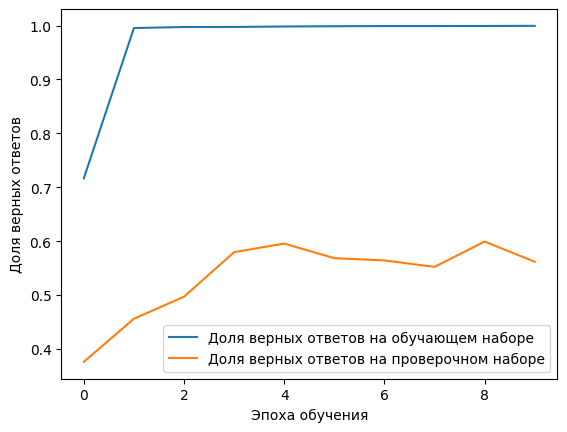

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 83s 567ms/step - accuracy: 0.8136 - loss: 0.6098 - val_accuracy: 0.2933 - val_loss: 1.8751
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 81s 587ms/step - accuracy: 0.9998 - loss: 0.0087 - val_accuracy: 0.3576 - val_loss: 1.5873
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 75s 537ms/step - accuracy: 0.9999 - loss: 0.0037 - val_accuracy: 0.4595 - val_loss: 1.3864
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 77s 558ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.5669 - val_loss: 1.1925
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 84s 611ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.6001 - val_loss: 1.1751
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 143s 614ms/step - accuracy: 1.0000 - loss: 9.6650e-04 - val_accuracy: 0.6261 - val_loss: 1.1565
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 94s 683ms/step - accuracy: 1.0000 - loss: 7.2727e-04 - val_accuracy: 0.6358 - val_loss: 1.1400
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 85s 619ms/step - accuracy: 1.0000 

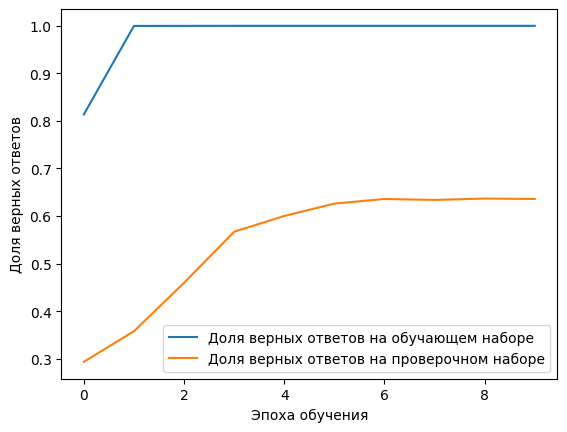

Epoch 1/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 390s 3s/step - accuracy: 0.8513 - loss: 0.5396 - val_accuracy: 0.3627 - val_loss: 1.6900
Epoch 2/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 455s 3s/step - accuracy: 0.9999 - loss: 0.0109 - val_accuracy: 0.3914 - val_loss: 1.4213
Epoch 3/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 418s 3s/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.5109 - val_loss: 1.2305
Epoch 4/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 376s 3s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.6119 - val_loss: 1.0624
Epoch 5/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 366s 3s/step - accuracy: 1.0000 - loss: 9.9557e-04 - val_accuracy: 0.6351 - val_loss: 1.0360
Epoch 6/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 410s 3s/step - accuracy: 1.0000 - loss: 7.2345e-04 - val_accuracy: 0.6541 - val_loss: 1.0102
Epoch 7/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 1.0000 - loss: 5.3385e-04 - val_accuracy: 0.6518 - val_loss: 1.0363
Epoch 8/10
138/138 ━━━━━━━━━━━━━━━━━━━━ 369s 3s/step - accuracy: 1.0000 - loss: 4.198

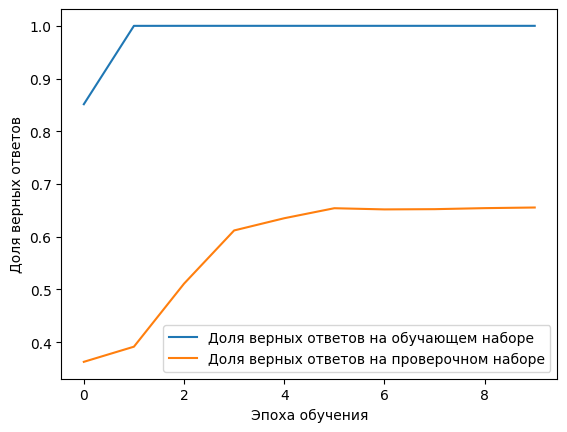

In [ ]:
maxWordsCount = 50000
tokenizer = Tokenizer(num_words=maxWordsCount, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0', lower=True, split=' ', oov_token='unknown', char_level=False)
tokenizer.fit_on_texts(trainText)
trainWordIndexes = tokenizer.texts_to_sequences(trainText)
testWordIndexes = tokenizer.texts_to_sequences(testText)

xLen = 1000
step = 100
xTrain, yTrain = createSetsMultiClasses(trainWordIndexes, xLen, step)
xTest, yTest = createSetsMultiClasses(testWordIndexes, xLen, step)

emb_space = [10, 50, 200]

for es in emb_space:
  model = Sequential([
      Embedding(maxWordsCount, es, input_length=xLen),
      SpatialDropout1D(0.2),
      Flatten(),
      BatchNormalization(),
      Dense(200, activation="relu"),
      Dropout(0.2),
      BatchNormalization(),
      Dense(6, activation='sigmoid')
  ])


  model.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

  history = model.fit(xTrain,
                      yTrain,
                      epochs=10,
                      batch_size=128,
                      validation_data=(xTest, yTest))

  scores = model.evaluate(xTest, yTest, verbose=1)

  print(f'\n{scores}')
  print("Доля верных ответов на тестовых данных: ", round(scores[1] * 100, 2), "%", sep="")

  plt.plot(history.history['accuracy'],
          label='Доля верных ответов на обучающем наборе')
  plt.plot(history.history['val_accuracy'],
          label='Доля верных ответов на проверочном наборе')
  plt.xlabel('Эпоха обучения')
  plt.ylabel('Доля верных ответов')
  plt.legend()
  plt.show()

**Вывод:** При росте embedding пространства точность сети возростает, но остается сравнительно ниже чем у bag-of-words за счет классификации автора по частоте используемых "любимых" слов.

# Pro

Добейтесь точности распознавания 97% и верно распознанных всех писателей с помощью любой нейронной сети без фильтрации данных.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.9947 - loss: 0.0239 - val_accuracy: 0.9646 - val_loss: 0.2077
Epoch 2/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 1.0000 - loss: 8.7024e-04 - val_accuracy: 0.9646 - val_loss: 0.1386
Epoch 3/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 1.0000 - loss: 4.1307e-04 - val_accuracy: 0.9659 - val_loss: 0.1234
Epoch 4/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 1.0000 - loss: 2.6350e-04 - val_accuracy: 0.9639 - val_loss: 0.1207
Epoch 5/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 1.0000 - loss: 1.6457e-04 - val_accuracy: 0.9660 - val_loss: 0.1146
Epoch 6/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 1.0000 - loss: 1.1582e-04 - val_accuracy: 0.9660 - val_loss: 0.1141
Epoch 7/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 1.0000 - loss: 8.9957e-05 - val_accuracy: 0.9637 - val_loss: 0.1095
Epoch 8/30
272/272 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 1.0000

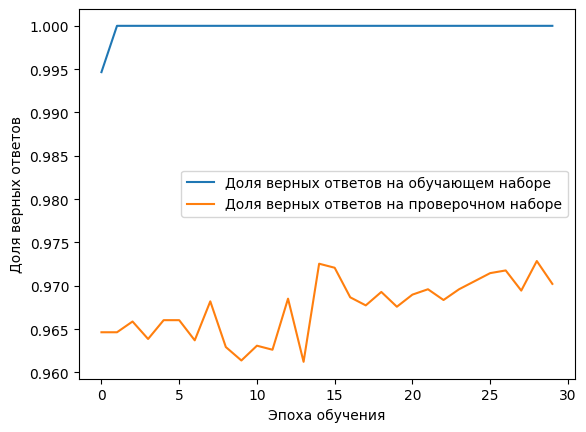

202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9702 - loss: 0.0932

[0.09317868202924728, 0.9702140688896179]
Доля верных ответов на тестовых данных: 97.02%
НЕЙРОНКА:  Тексты 01 + Dense

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Класс: О. Генри   100% сеть отнесла к классу О. Генри  Это ПРАВИЛЬНЫЙ ответ!
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Класс: Стругацкие 94% сеть отнесла к классу Стругацкие Это ПРАВИЛЬНЫЙ ответ!
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Класс: Булгаков   97% сеть отнесла к классу Булгаков   Это ПРАВИЛЬНЫЙ ответ!
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Класс: Саймак     96% сеть отнесла к классу Саймак     Это ПРАВИЛЬНЫЙ ответ!
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Класс: Фрай       95% сеть отнесла к классу Фрай       Это ПРАВИЛЬНЫЙ ответ!
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Класс: Брэдберри  100% сеть отнесла к классу Брэдберри Это ПРАВИЛЬНЫЙ ответ!

Средний процент распознавания 97%



In [ ]:
trainText = []
testText = []
for i in className:
  for j in os.listdir('texts/'):
    if i in j:
      if 'Обучающая' in j:
        trainText.append(readText('texts/' + j))
      if 'Тестовая' in j:
        testText.append(readText('texts/' + j))

cur_time = time.time()
maxWordsCount = 10000
tokenizer = Tokenizer(num_words=maxWordsCount, filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0', lower=True, split=' ', oov_token='unknown', char_level=False)
tokenizer.fit_on_texts(trainText)
trainWordIndexes = tokenizer.texts_to_sequences(trainText)
testWordIndexes = tokenizer.texts_to_sequences(testText)

def createTestMultiClasses(wordIndexes, xLen, step):
  nClasses = len(wordIndexes)
  xTest6Classes01 = []
  xTest6Classes = []
  for wI in wordIndexes:
    sample = (getSetFromIndexes(wI, xLen, step))
    xTest6Classes.append(sample)
    xTest6Classes01.append(tokenizer.sequences_to_matrix(sample))

  return xTest6Classes01, xTest6Classes

def recognizeMultiClass(model, xTest, modelName):
  print("НЕЙРОНКА: ", modelName)
  print()

  totalSumRec = 0

  for i in range(nClasses):
    currPred = model.predict(xTest[i])
    currOut = np.argmax(currPred, axis=1)

    evVal = []
    for j in range(nClasses):
      evVal.append(len(currOut[currOut==j])/len(xTest[i]))

    totalSumRec += len(currOut[currOut==i])
    recognizedClass = np.argmax(evVal)

    isRecognized = "Это НЕПРАВИЛЬНЫЙ ответ!"
    if (recognizedClass == i):
      isRecognized = "Это ПРАВИЛЬНЫЙ ответ!"
    str1 = 'Класс: ' + className[i] + " " * (11 - len(className[i])) + str(int(100*evVal[i])) + "% сеть отнесла к классу " + className[recognizedClass]
    print(str1, " " * (55-len(str1)), isRecognized, sep='')

  print()
  sumCount = 0
  for i in range(nClasses):
    sumCount += len(xTest[i])
  print("Средний процент распознавания ", int(100*totalSumRec/sumCount), "%", sep='')

  print()

  return totalSumRec/sumCount

xLen = 5000
step = 100
xTrain, yTrain = createSetsMultiClasses(trainWordIndexes, xLen, step)
xTest, yTest = createSetsMultiClasses(testWordIndexes, xLen, step)
xTrain01 = tokenizer.sequences_to_matrix(xTrain.tolist())
xTest01 = tokenizer.sequences_to_matrix(xTest.tolist())

model = Sequential([
    Dense(100, input_dim=maxWordsCount, activation='relu'),
    Dropout(0.2),
    Dense(50, input_dim=maxWordsCount, activation='sigmoid'),
    BatchNormalization(),
    Dense(6, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(xTrain01,
                      yTrain,
                      epochs=30,
                      batch_size=64,
                      validation_data=(xTest01, yTest))
plt.plot(history.history['accuracy'],
         label='Доля верных ответов на обучающем наборе')
plt.plot(history.history['val_accuracy'],
         label='Доля верных ответов на проверочном наборе')

plt.xlabel('Эпоха обучения')
plt.ylabel('Доля верных ответов')
plt.legend()
plt.show()

scores = model.evaluate(xTest01, yTest, verbose=1)
print(f'\n{scores}')
print("Доля верных ответов на тестовых данных: ", round(scores[1] * 100, 2), "%", sep="")

xTest6Classes01, _ = createTestMultiClasses(testWordIndexes, xLen, step)
pred = recognizeMultiClass(model, xTest6Classes01, "Тексты 01 + Dense")